In [ ]:
from dataset import *  # see note below
msg_path, ob_path = find_lobster_files("~/Desktop/LOBSTER", "AMZN")
print(msg_path.name, ob_path.name, sep="\n")

AMZN_2012-06-21_34200000_57600000_message_10.csv
AMZN_2012-06-21_34200000_57600000_orderbook_10.csv


In [ ]:
lob = load_raw(msg_path, ob_path)
lob.head()

,time,type,order_id,size,price,direction,ask_p1,ask_s1,bid_p1,bid_s1,...,bid_p8,bid_s8,ask_p9,ask_s9,bid_p9,bid_s9,ask_p10,ask_s10,bid_p10,bid_s10
0,34200.017460,5,0,1,2238200,-1,2239500,100,2231800,100,...,2202500,5000,2294300,100,2202000,100,2298000,100,2189700,100
1,34200.189608,1,11885113,21,2238100,1,2239500,100,2238100,21,...,2204000,100,2294300,100,2202500,5000,2298000,100,2202000,100
2,34200.189608,1,3911376,20,2239600,-1,2239500,100,2238100,21,...,2204000,100,2267700,100,2202500,5000,2294300,100,2202000,100
3,34200.189608,1,11534792,100,2237500,1,2239500,100,2238100,21,...,2213000,4000,2267700,100,2204000,100,2294300,100,2202500,5000
4,34200.189608,1,1365373,13,2240000,-1,2239500,100,2238100,21,...,2213000,4000,2267700,100,2204000,100,2294300,100,2202500,5000


In [ ]:
check_invariants(lob)

{'crossed': 0,
 'ask_ladder': 0,
 'bid_ladder': 0,
 'neg_size': 0,
 'dummy_levels': 0,
 'rows_violating': 0,
 'frac_violating': 0.0,
 'n_rows': 269748}

In [ ]:
bad = lob.head(5).copy()
bad.loc[0, "bid_p1"] = bad.loc[0, "ask_p1"]   # row 0: locked book (bid == ask)
bad.loc[1, "ask_p3"] = bad.loc[1, "ask_p2"]   # row 1: ask ladder not strictly increasing
bad.loc[2, "bid_s4"] = -1                     # row 2: negative size
check_invariants(bad)

{'crossed': 1,
 'ask_ladder': 1,
 'bid_ladder': 0,
 'neg_size': 1,
 'dummy_levels': 0,
 'rows_violating': 3,
 'frac_violating': 0.6,
 'n_rows': 5}

In [ ]:
lob["spread"] = lob["ask_p1"] - lob["bid_p1"]
lob.nlargest(30, "spread")[["time", "spread"]]

,time,spread
0,34200.017460,7700
1012,34334.776090,7500
1006,34334.650887,7400
1008,34334.650991,7400
1049,34341.811440,7300
1050,34341.861822,7300
1051,34341.867509,7300
1052,34341.867705,7300
1053,34341.876516,7300
1054,34341.876718,7300


In [ ]:
import importlib, dataset
importlib.reload(dataset)
from dataset import build_features

features, mid = build_features(lob)
print(features.shape, features.isna().sum().sum())
print("first / last step:", features.index[0], features.index[-1])
print("spread min (ticks):", features["spread"].min())
print("min gap (ticks):", features.filter(like="gap").min().min())
print(f"zero returns: {(features['ret'] == 0).mean():.1%}")

(4321, 40) 0
first / last step: 2012-06-21 09:45:00 2012-06-21 15:45:00
spread min (ticks): 1.0
min gap (ticks): 1.0
zero returns: 32.4%


In [ ]:
features.head()

,ret,spread,ask_gap1,bid_gap1,ask_gap2,bid_gap2,ask_gap3,bid_gap3,ask_gap4,bid_gap4,...,ask_logv6,bid_logv6,ask_logv7,bid_logv7,ask_logv8,bid_logv8,ask_logv9,bid_logv9,ask_logv10,bid_logv10
time,,,,,,,,,,,,,,,,,,,,,
2012-06-21 09:45:00,0.000022,27.0,2.0,5.0,2.0,4.0,10.0,6.0,3.0,1.0,...,4.615121,5.303305,4.615121,5.303305,4.615121,5.303305,4.615121,4.744932,5.303305,5.303305
2012-06-21 09:45:05,-0.000335,12.0,12.0,5.0,7.0,6.0,7.0,4.0,3.0,1.0,...,4.615121,5.303305,4.615121,5.993961,5.993961,4.744932,4.615121,5.303305,4.615121,5.303305
2012-06-21 09:45:10,-0.000022,11.0,1.0,5.0,9.0,6.0,10.0,4.0,5.0,1.0,...,4.615121,4.615121,4.615121,5.303305,4.615121,5.752573,4.615121,4.744932,5.993961,5.303305
2012-06-21 09:45:15,0.000022,12.0,13.0,5.0,6.0,6.0,6.0,4.0,3.0,1.0,...,4.615121,4.615121,4.615121,4.615121,4.615121,4.615121,5.707110,5.707110,4.615121,4.744932
2012-06-21 09:45:20,0.000000,12.0,13.0,5.0,6.0,6.0,6.0,4.0,3.0,1.0,...,4.615121,4.615121,4.615121,4.615121,4.615121,4.615121,5.707110,5.707110,4.615121,4.744932


In [ ]:
train, val, test, stats = split_and_normalise(features)
print(len(train), len(val), len(test))
print(round(train.mean().abs().max(), 6), round(train.std().mean(), 3))
print(round(val.mean().abs().max(), 3), round(test.mean().abs().max(), 3))

2880 720 721
0.0 1.0
0.442 0.393


In [ ]:
test.head()

,ret,spread,ask_gap1,bid_gap1,ask_gap2,bid_gap2,ask_gap3,bid_gap3,ask_gap4,bid_gap4,...,ask_logv6,bid_logv6,ask_logv7,bid_logv7,ask_logv8,bid_logv8,ask_logv9,bid_logv9,ask_logv10,bid_logv10
time,,,,,,,,,,,,,,,,,,,,,
2012-06-21 14:45:00,0.015404,-0.685888,-0.577430,0.124308,-0.549835,0.065915,-0.572350,-0.599091,-0.571618,-0.581881,...,-1.342482,-1.628740,-0.059552,0.427226,-0.245688,-0.409314,1.827004,0.322278,0.589998,0.835421
2012-06-21 14:45:05,0.015404,-0.685888,-0.577430,0.124308,-0.549835,0.065915,-0.572350,-0.599091,-0.571618,-0.581881,...,-1.342482,-1.628740,-0.059552,0.841844,-0.245688,-0.409314,1.602306,0.802883,0.589998,0.835421
2012-06-21 14:45:10,0.015404,-0.685888,-0.068245,-0.743585,-0.549835,0.065915,-0.572350,0.193459,1.162200,-0.581881,...,0.115457,0.093239,-0.059552,-1.942139,1.586780,0.839530,0.602913,-0.496793,-3.102006,0.835421
2012-06-21 14:45:15,0.243898,-0.235715,-0.577430,-0.309639,-0.549835,-0.595531,1.050858,0.193459,0.295291,-0.581881,...,1.557278,0.675769,0.723597,-0.279387,-2.782704,0.839530,0.641074,-2.424174,-0.265921,0.835421
2012-06-21 14:45:20,0.015404,-0.235715,-0.577430,-0.309639,-0.549835,-0.595531,1.050858,0.193459,0.295291,-0.581881,...,1.557278,0.675769,0.723597,-0.279387,-2.782704,0.909533,0.641074,0.802883,-0.265921,0.835421


In [ ]:
train_loader, val_w, test_w, stats = get_data("~/Desktop/LOBSTER")
batch, = next(iter(train_loader))
print(len(train_loader.dataset), batch.shape, val_w.shape, test_w.shape)

2857 torch.Size([128, 24, 40]) torch.Size([697, 24, 40]) torch.Size([698, 24, 40])


In [ ]:
import torch
torch.set_printoptions(precision=3, sci_mode=False, linewidth=200)

print(batch[0, :5, :8])      # one training window: first 5 steps, first 8 features
print(val_w[0, :5, :8])      # first validation window
print(test_w[0, :5, :8])     # first test window

tensor([[ 0.242, -1.586,  0.441,  3.162,  0.128, -0.596, -0.572, -0.599],
        [ 0.469, -1.136, -0.068, -0.744, -0.550,  4.035,  1.051,  0.193],
        [ 0.015, -1.136, -0.068,  2.728, -0.550,  0.066,  1.051, -0.599],
        [ 0.015, -1.136, -0.068,  3.596, -0.550, -0.596,  1.051, -0.599],
        [ 0.242, -1.586,  1.968,  3.162, -0.550, -0.596,  0.239, -0.599]])
tensor([[ 2.072, -1.136,  0.441,  3.162, -0.550, -0.596, -0.572,  0.986],
        [ 1.157, -0.686, -0.577,  0.558,  0.128,  0.066, -0.572,  1.779],
        [-0.441,  0.214, -0.577,  0.558, -0.550,  0.066, -0.572, -0.599],
        [ 0.015,  0.214, -0.068,  0.124, -0.550, -0.596, -0.572,  0.193],
        [ 0.358,  0.890, -0.577, -0.310,  0.128, -0.596, -0.572, -0.599]])
tensor([[ 0.015, -0.686, -0.577,  0.124, -0.550,  0.066, -0.572, -0.599],
        [ 0.015, -0.686, -0.577,  0.124, -0.550,  0.066, -0.572, -0.599],
        [ 0.015, -0.686, -0.068, -0.744, -0.550,  0.066, -0.572,  0.193],
        [ 0.244, -0.236, -0.577, -0.

In [ ]:
from modules import Generator, Discriminator
import torch 

G, D = Generator(), Discriminator()
z = torch.randn(128, 24, 40)                     # a batch of noise
fake = G(z)
print(fake.shape, D(fake).shape, D(batch).shape)
print(sum(p.numel() for p in G.parameters()), sum(p.numel() for p in D.parameters()))

ImportError: cannot import name 'Generator' from 'modules' (/Users/angusslater/Desktop/PatternAnalysis-2026/recognition/TimeGAN_LOB_s4961587/modules.py)

In [ ]:
from modules import Generator
import matplotlib.pyplot as plt

ckpt = torch.load("checkpoints/rnngan.pt", weights_only=False)   # stats are pandas objects, so not weights-only
G = Generator(); G.load_state_dict(ckpt["G"]); G.eval()
mean = torch.tensor(ckpt["stats"]["mean"].to_numpy(), dtype=torch.float32)
std = torch.tensor(ckpt["stats"]["std"].to_numpy(), dtype=torch.float32)

with torch.no_grad():
    fake = G(torch.randn(len(val_w), 24, 40)) * std + mean        # un-normalise to real units
real = val_w * std + mean
cols = list(ckpt["stats"]["mean"].index)
sp, gaps = cols.index("spread"), [i for i, c in enumerate(cols) if "gap" in c]

print(f"Spread mean (ticks)      real {real[..., sp].mean():6.2f}   fake {fake[..., sp].mean():6.2f}   expect similar")
print(f"Spread std  (ticks)      real {real[..., sp].std():6.2f}   fake {fake[..., sp].std():6.2f}   expect similar")
print(f"Crossed books (spread<=0) fake {(fake[..., sp] <= 0).float().mean():.2%}   expect 0% (real is 0%)")
print(f"Gaps < 1 tick            fake {(fake[..., gaps] < 1).float().mean():.2%}   expect ~0% (real is 0%)")
print(f"Return std (bps)         real {real[..., 0].std()*1e4:6.3f}   fake {fake[..., 0].std()*1e4:6.3f}   expect similar")
print(f"Diversity: std across windows of spread  real {real[:, :, sp].mean(1).std():.2f}   fake {fake[:, :, sp].mean(1).std():.2f}   fake << real means mode collapse")

Spread mean (ticks)      real  11.38   fake   8.97   expect similar
Spread std  (ticks)      real   3.60   fake   1.86   expect similar
Crossed books (spread<=0) fake 0.00%   expect 0% (real is 0%)
Gaps < 1 tick            fake 19.87%   expect ~0% (real is 0%)
Return std (bps)         real  1.507   fake  0.717   expect similar
Diversity: std across windows of spread  real 1.61   fake 0.16   fake << real means mode collapse


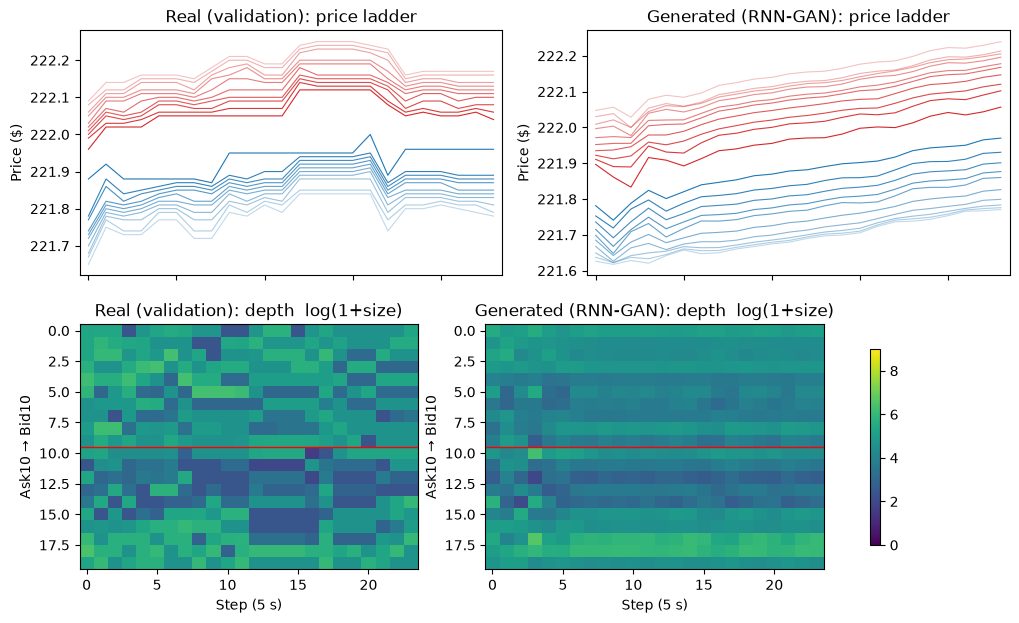

In [ ]:
TICK = 100
ask_g = [cols.index(f"ask_gap{i}") for i in range(1, 10)]
bid_g = [cols.index(f"bid_gap{i}") for i in range(1, 10)]
ask_v = [cols.index(f"ask_logv{i}") for i in range(1, 11)]
bid_v = [cols.index(f"bid_logv{i}") for i in range(1, 11)]

def to_book(w, mid0):
    """One window in real units (24, 40) -> ask/bid prices (24, 10) in LOBSTER units, plus volumes."""
    mid_t = mid0 * torch.exp(torch.cumsum(w[:, 0], 0))                     # rebuild mid from log returns
    half = w[:, 1:2] * TICK / 2                                              # half the spread
    zero = torch.zeros(len(w), 1)
    asks = (mid_t[:, None] + half) + TICK * torch.cat([zero, torch.cumsum(w[:, ask_g], 1)], 1)
    bids = (mid_t[:, None] - half) - TICK * torch.cat([zero, torch.cumsum(w[:, bid_g], 1)], 1)
    return asks, bids, w[:, ask_v], w[:, bid_v]                              # volumes left as log(1+size)

mid0 = float(mid.iloc[2879])               # real mid at 13:44:55, just before the validation hour
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for col, (name, w) in enumerate([("Real (validation)", real[0]), ("Generated (RNN-GAN)", fake[0])]):
    asks, bids, av, bv = to_book(w, mid0)
    ax = axes[0, col]
    for i in range(10):                    # price ladder: lines should NEVER cross
        ax.plot(asks[:, i] / 1e4, color="tab:red", lw=0.8, alpha=1 - i * 0.08)
        ax.plot(bids[:, i] / 1e4, color="tab:blue", lw=0.8, alpha=1 - i * 0.08)
    ax.set(title=f"{name}: price ladder", ylabel="Price ($)")
    hm = torch.cat([av.flip(1), bv], 1).T  # rows: Ask10 … Ask1, Bid1 … Bid10
    im = axes[1, col].imshow(hm, aspect="auto", cmap="viridis", vmin=0, vmax=9)
    axes[1, col].axhline(9.5, color="red", lw=1)
    axes[1, col].set(title=f"{name}: depth  log(1+size)", xlabel="Step (5 s)", ylabel="Ask10 → Bid10")
fig.colorbar(im, ax=axes[1, :], shrink=0.8); plt.show()

In [ ]:
print(f"Mean 5s return (bps)   real val {real[..., 0].mean()*1e4:+.3f}   fake {fake[..., 0].mean()*1e4:+.3f}   expect ~0 for both")
print(f"Share of fake windows trending up: {(fake[..., 0].sum(1) > 0).float().mean():.0%}   expect ~50%")

Mean 5s return (bps)   real val -0.008   fake +0.323   expect ~0 for both
Share of fake windows trending up: 100%   expect ~50%


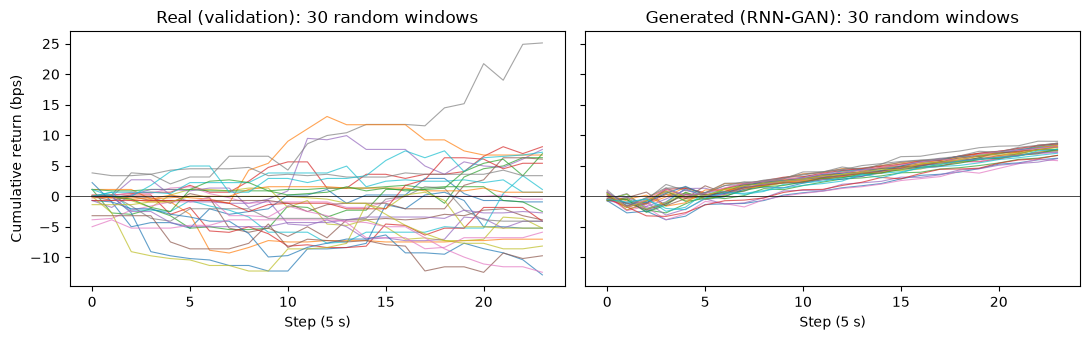

In [ ]:
from pathlib import Path
FIG = Path("~/Desktop/PatternAnalysis-2026/recognition/TimeGAN_LOB_s4961587/figures").expanduser()
FIG.mkdir(exist_ok=True)

idx = torch.randperm(len(fake))[:30]                       # 30 random windows, not hand-picked
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, (name, data) in zip(axes, [("Real (validation)", real), ("Generated (RNN-GAN)", fake)]):
    paths = torch.cumsum(data[idx, :, 0], 1) * 1e4        # cumulative log return in bps, start = 0
    ax.plot(paths.T, lw=0.8, alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.set(title=f"{name}: 30 random windows", xlabel="Step (5 s)")
axes[0].set_ylabel("Cumulative return (bps)")
fig.tight_layout(); fig.savefig(FIG / "paths_real_vs_rnngan.png", dpi=150); plt.show()

Metric                                     real (val)    generated  ref (train)   note
--------------------------------------------------------------------------------------------------------
Spread mean (ticks)                            11.381        8.973       13.029   
Spread std (ticks)                              3.598        1.870        4.440   
5s return std (bps)                             1.507        0.718        1.966   
Mean 5s return (bps)                           -0.008        0.324       -0.026   expect ~0 (no drift)
Windows trending up (%)                        46.915      100.000       47.637   expect ~50
Zero returns (%)                               36.585        7.544       31.919   
Diversity: std of window-mean spread            1.606        0.158        2.444   fake << real = mode collapse
Vol clustering: ACF |ret| lag 1                 0.103        0.196        0.105   > 0 = clustering
Crossed books (%)                               0.000        0.000    

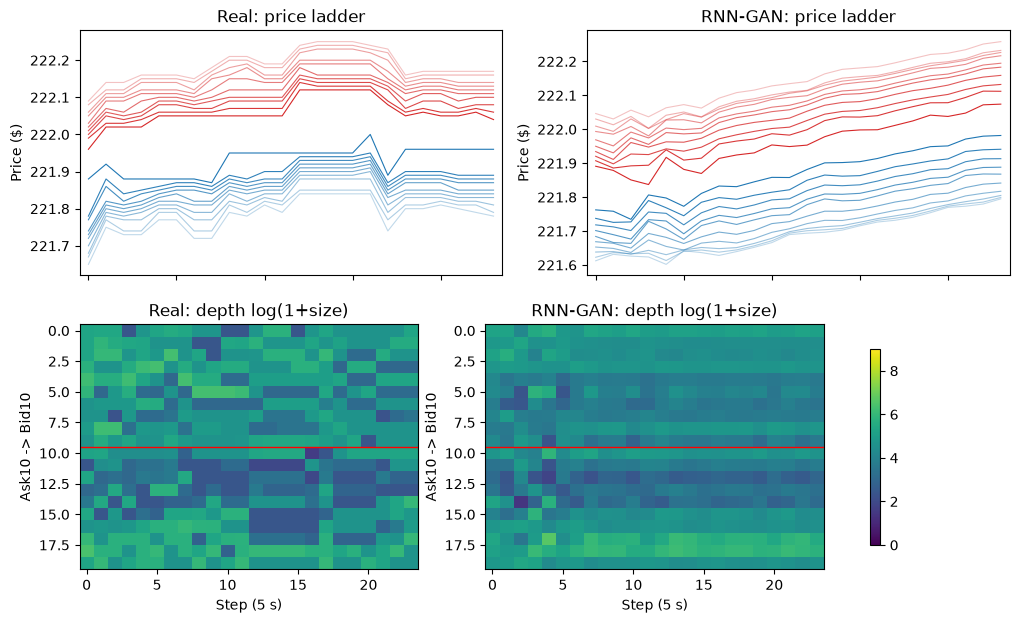

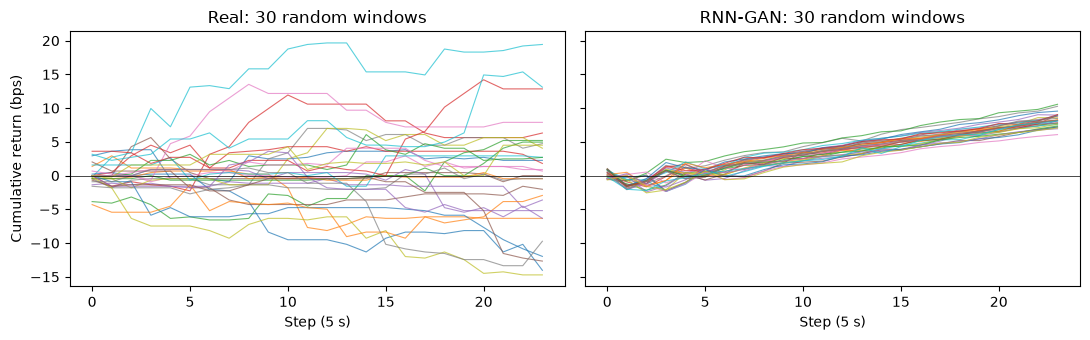

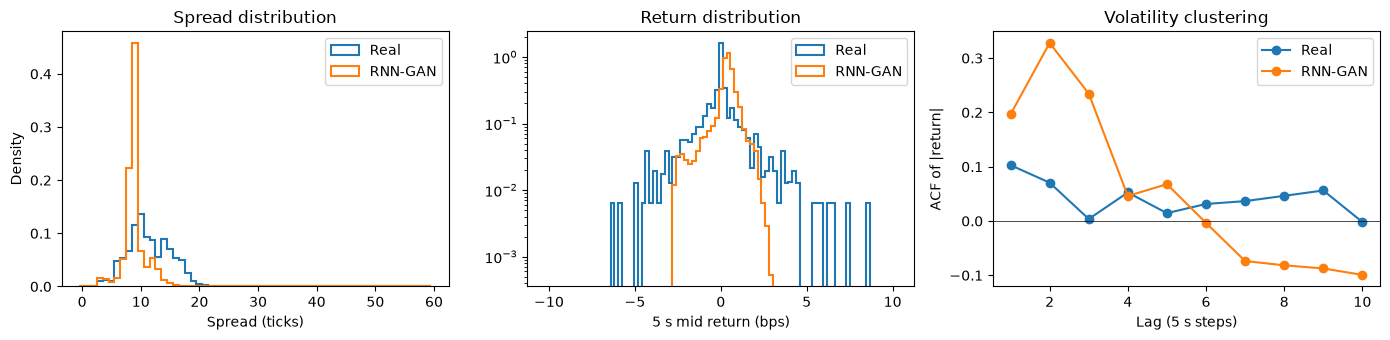

In [ ]:
%load_ext autoreload
%autoreload 2
import torch, matplotlib.pyplot as plt
from pathlib import Path
from dataset import get_data, find_lobster_files, load_raw, build_features
from modules import Generator
import utils

FIG = Path("~/Desktop/PatternAnalysis-2026/recognition/TimeGAN_LOB_s4961587/figures").expanduser()
train_loader, val_w, test_w, stats = get_data("~/Desktop/LOBSTER")
train_w = train_loader.dataset.tensors[0]                     # all 2857 training windows, in time order

ckpt = torch.load("checkpoints/rnngan.pt", weights_only=False)
G = Generator(); G.load_state_dict(ckpt["G"]); G.eval()
torch.manual_seed(0)                                          # reproducible samples
with torch.no_grad():
    fake = G(torch.randn(len(val_w), 24, 40))

out = utils.evaluate(val_w, fake, stats, ref_w=train_w)
utils.print_report(out)

_, mid = build_features(load_raw(*find_lobster_files("~/Desktop/LOBSTER")))
mid0 = float(mid.iloc[2879])                                  # real mid just before validation starts
utils.plot_book_comparison(val_w, fake, stats, mid0=mid0, label="RNN-GAN", path=FIG / "rnngan_book.png")
utils.plot_paths(val_w, fake, stats, label="RNN-GAN", path=FIG / "rnngan_paths.png")
utils.plot_distributions(val_w, fake, stats, label="RNN-GAN", path=FIG / "rnngan_dists.png")
plt.show()

In [ ]:
from modules import TGGenerator
G = TGGenerator()
e = G(torch.randn(128, 24, 40))
print(f"Generator output (windows, steps, latent): {tuple(e.shape)}   expect (128, 24, 24)")
print(f"Output range: {e.min():.3f} to {e.max():.3f}   expect within 0 to 1 (sigmoid)")
print(f"Parameters: {sum(p.numel() for p in G.parameters()):,}")

Generator output (windows, steps, latent): (128, 24, 24)   expect (128, 24, 24)
Output range: 0.413 to 0.611   expect within 0 to 1 (sigmoid)
Parameters: 12,552


In [ ]:
from modules import TGEmbedder
import torch
E = TGEmbedder()
h = E(torch.randn(128, 24, 40))
print(f"Embedder output (windows, steps, latent): {tuple(h.shape)}   expect (128, 24, 24)")
print(f"Output range: {h.min():.3f} to {h.max():.3f}   expect within 0 to 1")
print(f"Parameters: {sum(p.numel() for p in E.parameters()):,}   expect 12,552 (same sizes as the generator)")

Embedder output (windows, steps, latent): (128, 24, 24)   expect (128, 24, 24)
Output range: 0.394 to 0.586   expect within 0 to 1
Parameters: 12,552   expect 12,552 (same sizes as the generator)


In [ ]:
from modules import TGRecovery
R = TGRecovery()
x = R(torch.rand(128, 24, 24))                  # rand = values in [0, 1], like real latents
print(f"Recovery output (windows, steps, features): {tuple(x.shape)}   expect (128, 24, 40)")
print(f"Output range: {x.min():.3f} to {x.max():.3f}   expect values below 0 are possible (no sigmoid)")
print(f"Parameters: {sum(p.numel() for p in R.parameters()):,}   expect 11,800")

Recovery output (windows, steps, features): (128, 24, 40)   expect (128, 24, 40)
Output range: -0.367 to 0.348   expect values below 0 are possible (no sigmoid)
Parameters: 11,800   expect 11,800


In [ ]:
from modules import TGSupervisor
S = TGSupervisor()
s = S(torch.rand(128, 24, 24))
print(f"Supervisor output (windows, steps, latent): {tuple(s.shape)}   expect (128, 24, 24)")
print(f"Output range: {s.min():.3f} to {s.max():.3f}   expect within 0 to 1")
print(f"Parameters: {sum(p.numel() for p in S.parameters()):,}   expect 7,800")

H = torch.rand(128, 24, 24)
loss = torch.nn.functional.mse_loss(S(H)[:, :-1], H[:, 1:])
print(f"Untrained supervised loss: {loss.item():.4f}   expect roughly 0.08-0.12 (random guesses on [0,1] data)")